## Aufgabe 7 | Regionen in Binärbildern
#### Ahmed Adnan,  Eugen Erb, Nicolas Huhle

#### What we need to do:
In this assignment, we implement a method to detect and label connected regions in a binary image.

The goal is to assign a unique label to each group of connected foreground pixels (value = 1), using a two-step algorithm:
1. **First pass**: Assign temporary labels and track label collisions.
2. **Second pass**: Resolve collisions and update all labels.

This helps us identify and separate different objects in the image.


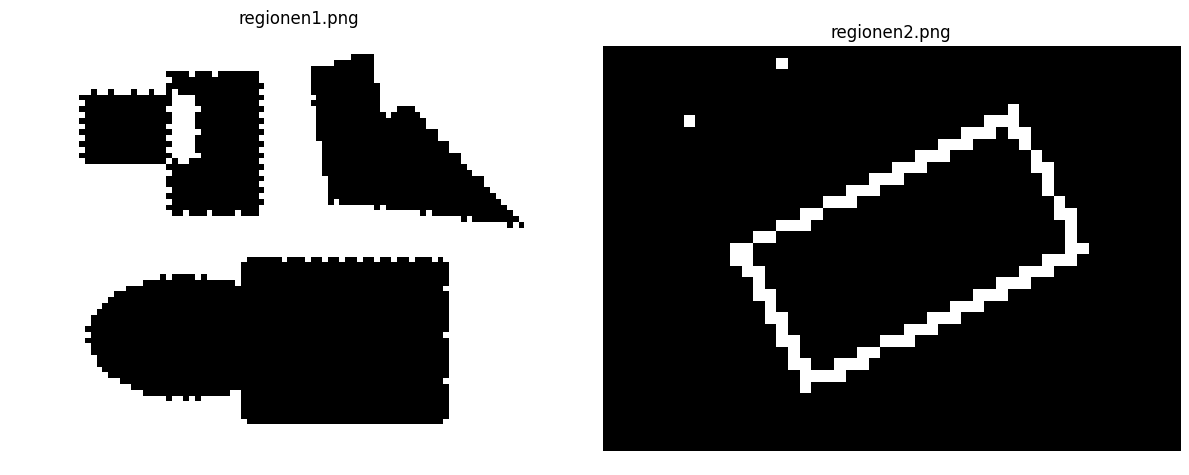

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

# Load and convert both images to grayscale
image1 = Image.open("regionen1.png").convert("L")
image2 = Image.open("regionen2.png").convert("L")

# Convert to numpy arrays
image1_np = np.array(image1)
image2_np = np.array(image2)

# Display the images
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image1_np, cmap='gray')
plt.title("regionen1.png")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image2_np, cmap='gray')
plt.title("regionen2.png")
plt.axis('off')

plt.tight_layout()
plt.show()

#### how do we start?
To start, we define a function that converts a grayscale image into a binary image using a fixed threshold. 
All pixel values above the threshold become 1 (foreground), and the rest become 0 (background). 
We also test it with a small example image.

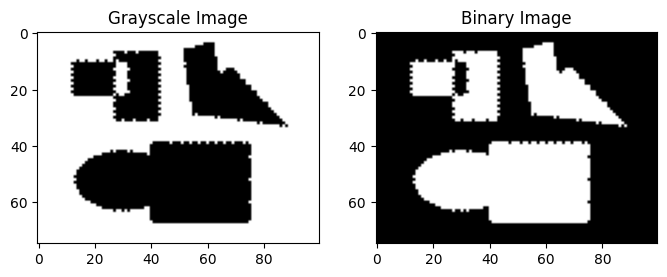

In [108]:
# Function to convert a grayscale image to binary
def binarize_image(image: np.ndarray, threshold: int = 128, background: str = "black") -> np.ndarray:
    """
    Convert a grayscale image to binary format, with customizable background color.

    Parameters:
        image (np.ndarray): Grayscale image (values 0–255)
        threshold (int): Threshold for binarization
        background (str): "black" (default) or "white"

    Returns:
        np.ndarray: Binary image with foreground = 1, background = 0
    """
    if background == "black":
        return np.where(image >= threshold, 1, 0)
    elif background == "white":
        return np.where(image <= threshold, 1, 0)
    else:
        raise ValueError("background must be 'black' or 'white'")


# Example
test_image = np.array([
    [90, 0, 255, 212, 50, 88, 220, 120, 55, 20],
    [175, 65, 130, 144, 120, 168, 185, 102, 150, 88],
   [114, 82, 25, 121, 99, 44, 211, 111, 85, 55],
   [162, 185, 225, 212, 150, 188, 220, 140, 205, 28],
   [169, 144, 202, 172, 180, 158, 220, 120, 55, 100]
], dtype=np.uint8)

# Apply binarization
binary_image = binarize_image(image1_np, threshold=128, background="white")

# Display both original and binary images
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title("Grayscale Image")
plt.imshow(image1_np, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Binary Image")
plt.imshow(binary_image, cmap='gray')
plt.show()


First Pass – Provisional Labeling and Collision Detection

In [109]:
def first_pass(binary_image: np.ndarray):
    """
    Perform the first pass of sequential region labeling on a binary image.

    Each foreground pixel (value = 1) is assigned a provisional label.
    Collisions (equivalent labels) are recorded and merged if needed.

    Parameters:
        binary_image (np.ndarray): Binary image with values 0 (background) or 1 (foreground).

    Returns:
        label_matrix (np.ndarray): Matrix with provisional labels.
        equivalences (list of sets): Cleaned list of merged equivalence sets.
    """
    height, width = binary_image.shape
    label_matrix = np.zeros((height, width), dtype=int)
    current_label = 1
    equivalences = []

    for y in range(height):
        for x in range(width):
            if binary_image[y, x] == 0:
                continue

            neighbors = []

            if y > 0 and label_matrix[y - 1, x] > 0:
                neighbors.append(label_matrix[y - 1, x])
            if x > 0 and label_matrix[y, x - 1] > 0:
                neighbors.append(label_matrix[y, x - 1])

            if not neighbors:
                label_matrix[y, x] = current_label
                equivalences.append(set([current_label]))
                current_label += 1
            else:
                min_label = min(neighbors)
                label_matrix[y, x] = min_label

                for lbl in neighbors:
                    if lbl != min_label:
                        # Merge sets if they intersect
                        merged = False
                        new_set = set([min_label, lbl])
                        to_merge = []

                        for eq_set in equivalences:
                            if not eq_set.isdisjoint(new_set):
                                new_set.update(eq_set)
                                to_merge.append(eq_set)

                        # Remove merged sets
                        for eq_set in to_merge:
                            equivalences.remove(eq_set)

                        # Add the merged result
                        equivalences.append(new_set)

    return label_matrix, equivalences


In [110]:
binary_image1 = binarize_image(image2_np, threshold=128)

# Apply first pass to the binarized image
label_matrix1, equivalences1 = first_pass(binary_image)

# Display the label matrix
df = pd.DataFrame(label_matrix1)
print("Label Matrix (First Pass) – regionen1")
display(df)

Label Matrix (First Pass) – regionen1


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
71,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
72,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
73,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [111]:
def second_pass(label_matrix: np.ndarray, equivalences: list[set]) -> np.ndarray:
    """
    Perform the second pass: resolve provisional labels using the equivalence sets.

    Parameters:
        label_matrix (np.ndarray): Provisional label matrix from first pass.
        equivalences (list of sets): List of label groups that should be merged.

    Returns:
        np.ndarray: Final label matrix with resolved labels.
    """
    # Build label mapping: each label → smallest label in its equivalence set
    label_map = {}
    for eq_set in equivalences:
        min_label = min(eq_set)
        for label in eq_set:
            label_map[label] = min_label

    # Replace each label in the matrix using the mapping
    height, width = label_matrix.shape
    final_matrix = np.zeros((height, width), dtype=int)

    for y in range(height):
        for x in range(width):
            label = label_matrix[y, x]
            if label == 0:
                continue  # background
            final_matrix[y, x] = label_map.get(label, label)

    return final_matrix


In [112]:
final_matrix = second_pass(label_matrix1, equivalences1)
# Display the label matrix
df = pd.DataFrame(final_matrix)
print("Label Matrix (First Pass) – regionen1")
display(df)

Label Matrix (First Pass) – regionen1


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
71,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
72,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
73,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


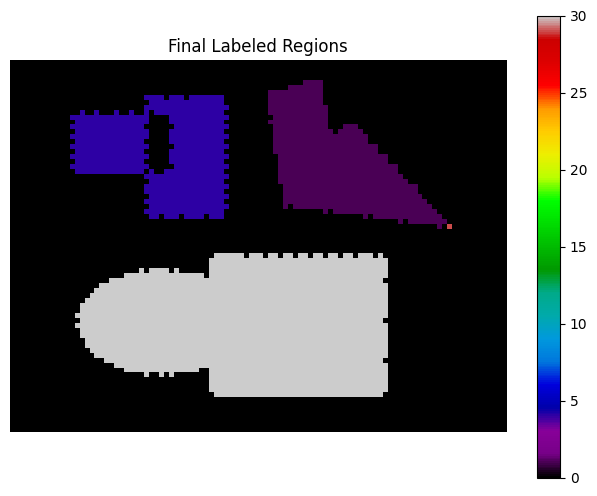

In [113]:
def visualize_labels(label_matrix: np.ndarray, title: str = "Labeled Image"):
    """
    Visualize a labeled matrix with different colors for each label.
    
    Parameters:
        label_matrix (np.ndarray): Matrix with region labels.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(8, 6))
    plt.imshow(label_matrix, cmap="nipy_spectral")
    plt.title(title)
    plt.axis("off")
    plt.colorbar()
    plt.show()

# Call it like this:
visualize_labels(final_matrix, title="Final Labeled Regions")



In [114]:
def count_regions(label_matrix: np.ndarray) -> int:
    labels = np.unique(label_matrix)
    return len(labels[labels > 0])  # exclude background (label 0)

# Example usage:
region_count = count_regions(final_matrix)
print(f"Number of connected regions: {region_count}")


Number of connected regions: 4
